<a href="https://colab.research.google.com/github/MAngelica-Sandoval/Proyecto-Analisis-de-Datos-NORM/blob/main/sesiones_practica/sp_1_Maria_Sandoval.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Analisis de datos Modaria II.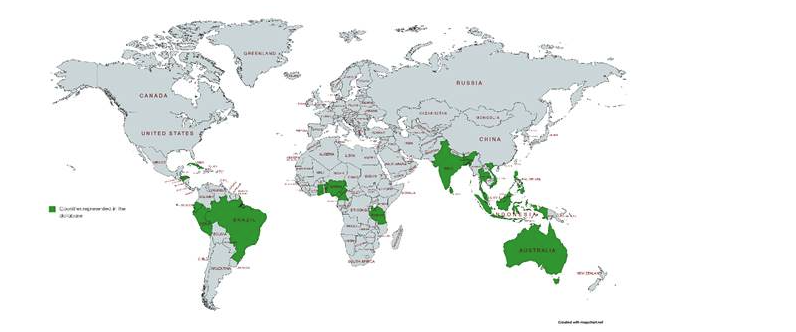

# Preparación de la fuente de datos y librerías

In [23]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Cargar el archivo en CSV, la base de datos esta en el repo.
df = pd.read_csv('iaea-modaria-ii-tropical-dataset (2).csv')


# 1. Introducción



**Definición del problema y justificación de la base de datos**


---


**1.   Breve presentación del problema o pregunta de investigación.**

Mi problema de investigación se basa en entender cómo se distribuyen los radionucleidos en los organismos vivos, en este caso las plantas, ya que mi tesis se centrará en buscar potenciales agentes bioremediadores (hongos) para tratar los sitios contaminados por radiación que provienen de las diferentes industrias con residuos radiactivos y que tienen pasivos ambientales con un alto nivel de radiación. Este conjunto de datos es adecuado porque me puede dar una idea de cómo es la acumulación de estos materiales en los diferentes compartimentos de una planta. De esta necesidad me planteo las siguientes preguntas:

¿Las plantas en el trópico absorben radionúclidos junto con metales pesados que puedan facilitar su ingreso al acumularse en sus compartimentos (raíz, hoja, tallo)? ¿En qué compartimentos hay una mayor acumulación? ¿Existen propiedades del suelo que faciliten este proceso de absorción de radionúclidos?

**2.  Contexto: ¿por qué es relevante este problema?**

La radiación es un fenómeno que siempre nos acompaña; recibimos radiación en todo momento debido a los rayos cósmicos, a los materiales radiactivos de origen natural presentes en materiales de construcción, y al radón en el aire, lo que se conoce como los NORM. Además de esta dosis de radiación que recibimos, en la historia se marcaron varios eventos con la emisión de elementos radiactivos artificiales, tales como accidentes en plantas nucleares y armas nucleares. Estos eventos dispersaron radionucleidos con alta energía a nivel global.
El estudio de la acumulación de radionúclidos en la biota global es de gran importancia para entender cómo fue su dispersión y qué tanto avanzaron estos elementos. Sin embargo, esta acumulación puede aumentar el riesgo de irradiación interna, integrándose en los tejidos vegetales. Estos radionúclidos entran directamente en la cadena trófica, representando una amenaza para la salud humana al incorporarse en el ciclo alimentario.
Por tanto, es de gran importancia comenzar a entender la dinámica y el comportamiento de estos materiales en el suelo y su transferencia a los cultivos, ya que solo comprendiendo estas interacciones podremos mitigar el riesgo radiológico y proteger la integridad de nuestros recursos.


**3. Relación entre el problema y la base de datos seleccionada.**

Para abordar este problema y poder responder las preguntas planteadas, utilizare el conjunto de datos de la  IAEA - MODARIA II Tropical Dataset, este compila la información de transferencia de radionuclidos  a las plantas tropicales y en qué compartimiento se encontraron. Este dataset recopila más de 7,000 registros de 21 países e incluye mediciones de 36 elementos químicos, entre los que se encuentran radionúclidos de las cadenas naturales del uranio y el torio, así como metales pesados y nutrientes esenciales [1](https:////data.iaea.org/dataset/modaria/resource/42c148b5-f43d-4b6f-b521-e4197fc23823?view_id=37c6d53b-8001-4e76-ba82-557d0af9a7d1).


La configuracion de los datos y su clasificacion por compartimientos vegetales como raíces, hojas y frutos, espero que me permita analizar propiedades de coacumulación, facilitando la identificación de qué variables del suelo y qué interacciones químicas facilitan o impiden que la radiactividad entre en la cadena trófica a través de los cultivos.




# 2. **Descripción de la base de datos**

**2.1 Estructura general y muestra de datos.**

El dataset contiene información sobre la transferencia de elementos desde el suelo a las plantas en climas tropicales, organizada por países, tipos de cultivo y condiciones ambientales.

In [24]:
# 1. Visualizar una pequeña muestra de los datos
df.head()

,_id,Record,Element,Radionuclide,Common name,Latin name,Compartment,CR,Uncert._CR,N_CR,...,OM,Exch. K,Exch. Ca,Exch. Mg,CEC,pH,QC meas.,QC sampl.,QC equip.,Reference
0,1,1,Cr,NaN,Potato,Solanum tuberosum,Tubers,3.60E-02,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,1.0,1.0,1.0,1
1,2,2,Co,NaN,Potato,Solanum tuberosum,Tubers,1.70E-02,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,1.0,1.0,1.0,1
2,3,3,Ni,NaN,Potato,Solanum tuberosum,Tubers,3.70E-02,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,1.0,1.0,1.0,1
3,4,4,Cu,NaN,Potato,Solanum tuberosum,Tubers,2.50E-01,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,1.0,1.0,1.0,1
4,5,5,Pb,NaN,Potato,Solanum tuberosum,Tubers,1.60E-02,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,1.0,1.0,1.0,1


In [25]:
# 2. Número de registros y variables
print(f"Número de registros: {df.shape[0]}")
print(f"Número de variables: {df.shape[1]}")

Número de registros: 7151
Número de variables: 42


In [26]:
# Tipos de datos
print("\nTipos de datos por variable:")
print(df.dtypes.value_counts())

# Clasificación de variables (basado en las columnas del dataset MODARIA)
categoricas = df.select_dtypes(include=['object']).columns.tolist()
numericas = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

print("🔹 Variables categóricas:")
print("\n".join([f"- {col}" for col in categoricas[:30]]))

print("\n🔸 Variables numéricas:")
print("\n".join([f"- {col}" for col in numericas]))


Tipos de datos por variable:
object     23
float64    16
int64       3
Name: count, dtype: int64
🔹 Variables categóricas:
- Element
- Radionuclide
- Common name
- Latin name
- Compartment
- CR
- C_plant
- C_soil
- Country
- Site
- K-G class
- Contamination
- Experiment
- Year
- Growth stage
- Preparation
- Soil depth
- Texture
- Sand
- Silt
- Clay
- CEC
- pH

🔸 Variables numéricas:
- _id
- Record
- Uncert._CR
- N_CR
- Min_CR
- Max_CR
- Uncert._C_plant
- N_plant
- Uncert._C_soil
- N_soil
- Dry fraction
- OM
- Exch. K
- Exch. Ca
- Exch. Mg
- QC meas.
- QC sampl.
- QC equip.
- Reference


In [27]:
# Descripción general de las variables numéricas
print("\nDescripción de variables numéricas:")
print(df.describe())


Descripción de variables numéricas:
              _id      Record  Uncert._CR  N_CR        Min_CR      Max_CR  \
count  7151.00000  7151.00000  232.000000   0.0  1.680000e+02  168.000000   
mean   3576.00000  3576.00000    0.817625   NaN  6.594202e-01    5.092737   
std    2064.46022  2064.46022    3.149644   NaN  8.528416e-01   13.723478   
min       1.00000     1.00000    0.000009   NaN  2.200000e-07    0.000017   
25%    1788.50000  1788.50000    0.006525   NaN  1.062500e-01    0.384500   
50%    3576.00000  3576.00000    0.022000   NaN  3.915000e-01    1.160000   
75%    5363.50000  5363.50000    0.200000   NaN  9.117500e-01    3.375000   
max    7151.00000  7151.00000   37.000000   NaN  5.500000e+00  144.000000   

       Uncert._C_plant      N_plant  Uncert._C_soil       N_soil  \
count       954.000000  3883.000000     1419.000000  4473.000000   
mean        159.660245     2.666753       64.755224     6.190923   
std        1582.296561     9.397852      388.057824    25.799640 

**Tamaño :**  Hay un total de 7.151 registros, aunque no todas las variables contienen datos completos. Por ejemplo, variables como N_CR están completamente vacías (con 0 observaciones), mientras que otras, como _id, Record, QC meas., QC sampl., QC equip. y Reference, tienen datos en todos los registros (count = 7.151), lo que indica que son identificadores o controles fundamentales siempre presentes.
La mayoría de las variables presentan conteos bajos (por ejemplo, Uncert._CR con solo 232, aproximadamente un 3% completo; Exch. Mg con solo 193, aproximadamente un 3% completo), lo que indica una gran cantidad de datos faltantes en mediciones relacionadas con las propiedades del suelo, que es una situacion comun en datos ambientales específicos.

**Identificadores:** _id y Record son datos secuenciales que odentifican cada fila del dataset, no tienen significado ambiental,

**Incertidumbres y rangos de los ratios (Uncert._CR, Min_CR, Max_CR):**
La incertidumbre en el ratio de concentración (CR) es generalmente baja, con un promedio de 0,82, aunque presenta una variación (desviación estándar de 3,15 y un máximo de 37), y una mediana muy baja de 0,022.

**Propiedades de plantas y suelos (Dry fraction, OM, Exch. K, Ca, Mg):**
La fracción seca (Dry fraction) tiene un valor promedio de 0,25, con un rango de 0,04 a 0,88, indicando que las muestras generalmente contienen alrededor del 25% de materia seca. La materia orgánica (OM) promedia un 8,73%, con una mediana de 8,0 y un valor máximo de 150,5, típicos de suelos tropicales donde la descomposición orgánica es rápida. Los cationes intercambiables (Exch. K promedio 0,8; Ca 10,27; Mg 2,26) muestran poca variabilidad en la mediana (por ejemplo, K 0,51), pero la alta desviación estándar en Ca y Mg sugiere que la competencia entre estos cationes por la absorción en las raíces puede variar significativamente según el suelo.

**Controles de calidad (QC meas., sampl., equip.):**
Los promedios van de 0,67 a 0,93, con medianas de 1,0. La mayoría de los datos cumplen con los controles de calidad (son binarios: 0 = no pasa, 1 = sí pasa), especialmente en muestreo y equipo (más del 90% aprobados), lo que indica buena calidad general de los datos.

**Observaciones Gnerales**
Los valores tienen distribuciones sesgadas hacia arriba (las medianas son mucho menores que los promedios, y los máximos son muy altos), algo común en datos ambientales por la presencia de casos de contaminación .

# 3. Análisis inicial de las variables
- Identificación de las variables clave.
- Conteo de valores, tipos de datos y valores faltantes.

In [28]:
# Conteo de valores faltantes ordenado de mayor a menor con el porcentaje
total_filas = len(df)
faltantes = df.isnull().sum()
porcentaje = (faltantes / total_filas * 100).round(2)

df_resumen = pd.DataFrame({
    'Faltantes': faltantes,
    '% Faltantes': porcentaje
}).sort_values('% Faltantes', ascending=False)

df_resumen = df_resumen[df_resumen['Faltantes'] > 0]

print(f"Total filas: {total_filas:,}\n")
print("Variables con valores faltantes (ordenado por %):")
print(df_resumen)

Total filas: 7,151

Variables con valores faltantes (ordenado por %):
                 Faltantes  % Faltantes
N_CR                  7151       100.00
Min_CR                6983        97.65
Max_CR                6983        97.65
Exch. Mg              6958        97.30
Uncert._CR            6919        96.76
Exch. Ca              6918        96.74
Exch. K               6911        96.64
Uncert._C_plant       6197        86.66
Silt                  6139        85.85
Sand                  6139        85.85
Clay                  6093        85.20
OM                    6010        84.04
CEC                   5849        81.79
Uncert._C_soil        5732        80.16
Texture               5649        79.00
Dry fraction          5507        77.01
pH                    5479        76.62
CR                    4756        66.51
Radionuclide          4184        58.51
Preparation           4066        56.86
Growth stage          3944        55.15
N_plant               3268        45.70
Year      

In [29]:
# Conteo de valores únicos por variable
print("\nConteo de valores únicos por variable:")
print(df.nunique().sort_values(ascending=False))


Conteo de valores únicos por variable:
_id                7151
Record             7151
C_plant             743
C_soil              519
Site                462
CR                  404
Uncert._C_plant     271
Common name         249
Latin name          205
Uncert._C_soil      199
pH                  167
CEC                 158
Max_CR              147
Uncert._CR          135
Min_CR              120
OM                  119
Clay                102
Sand                101
Silt                100
Reference            94
Dry fraction         48
N_plant              40
Element              36
Year                 34
Compartment          32
Exch. Ca             28
N_soil               27
Exch. K              22
Country              21
Radionuclide         19
Exch. Mg             18
Soil depth           15
Texture              15
Contamination         4
Preparation           3
Growth stage          3
K-G class             3
Experiment            3
QC sampl.             3
QC meas.              3


**Mi pregunta es:** ¿Las plantas en el trópico absorben radionúclidos junto con metales pesados que puedan facilitar su ingreso al acumularse en sus compartimentos (raíz, hoja, tallo)? ¿En qué compartimentos hay una mayor acumulación? ¿Existen propiedades del suelo que faciliten este proceso de absorción de radionúclidos?

**Variables clave:**

De las 40 variables seleccione 9 ya que son las de importancia para resolver mi pregunta y que minimizan el impacto de datos faltantes. Las variables son:

* **Element, Radionuclide y Contamination:** estas tres variables me permiten identificar los radionúclidos (Cs-137, Ra-226, U) y metales pesados o isótopos estables (Cd, Pb, Ni, Cr, As) que pueden compartir mecanismos de absorcion, influir en la movilidad desde la mtriz suelo hasta la raiz y luego a los compartimientos.
* **Compartment, CR, C_plant y C_soil** estas variables son fundamentales para evaluar y comparar la acumulación  en los compartimentos raíz, hoja y tallo, ya que CR cuantifica la transferencia suelo-planta, mientras que C_plant y C_soil ofrecen concentraciones reales con excelente cobertura de datos (solo 11–17% de faltantes en C_plant y C_soil).
* **pH y OM**: auque estas variables tienen ~78–84% de faltantes es importante realizar un analisis de sus concentraciones, ya que ya que la literatura muestra que un pH bajo y baja materia orgánica incrementan la biodisponibilidad de cationes en suelos tropicales [2](https://www.mdpi.com/2571-8789/8/2/36).



In [30]:
# Lista de mis variables clave
variables_clave = [
    'Element',          # categórica - metales pesados y elementos
    'Radionuclide',     # categórica - radionúclidos específicos
    'Contamination',    # categórica - tipo (SI, N, etc.)
    'Compartment',      # categórica - root, leaf, stem, etc.
    'CR',               # numérica - ratio de concentración (acumulación)
    'C_plant',          # numérica - concentración en planta
    'C_soil',           # numérica - concentración en suelo
    'pH',               # numérica - propiedad edáfica clave
    'OM'                # numérica - materia orgánica
]

# 1. Vista rápida de las primeras filas de las variables clave
print("\n=== Vista rápida de las variables clave (primeras 5 filas) ===")
print(df[variables_clave].head())

# 2. Estadísticas descriptivas completas de las variables clave
print("\n=== Estadísticas descriptivas de las variables clave ===")
print(df[variables_clave].describe(include='all'))


=== Vista rápida de las variables clave (primeras 5 filas) ===
  Element Radionuclide Contamination Compartment        CR   C_plant  \
0      Cr          NaN            SI      Tubers  3.60E-02  1.60E+00   
1      Co          NaN            SI      Tubers  1.70E-02  4.20E-01   
2      Ni          NaN            SI      Tubers  3.70E-02  7.70E-01   
3      Cu          NaN            SI      Tubers  2.50E-01  4.60E+00   
4      Pb          NaN            SI      Tubers  1.60E-02  4.00E+00   

     C_soil   pH  OM  
0  4.90E+01  NaN NaN  
1  2.40E+01  NaN NaN  
2  2.50E+01  NaN NaN  
3  3.40E+01  NaN NaN  
4  1.40E+03  NaN NaN  

=== Estadísticas descriptivas de las variables clave ===
       Element Radionuclide Contamination Compartment        CR   C_plant  \
count     7151         2967          7151        7151      2395      6661   
unique      36           19             4          32       404       743   
top          K         K-40            SI      Fruits  1.20E-01  1.30E+01   

1. **Características Generales**

La variable **Element** presenta 36 categorías únicas, siendo el potasio el más frecuente con 775 registros, y en la variable **Radionuclide** se muestra que en específico el isótopo es el K-40, lo que me indica abundancia de radionúclidos naturales; sin embargo, las concentraciones de potasio son más elevadas en matrices naturales.

La variable **Contamination** es predominantemente el SI (isótopos estables/metales pesados) con 4.184 registros, indicando que una gran proporción de los datos incluye metales pesados o elementos estables junto a radionúclidos naturales.

La variable **Compartment** tiene 32 categorías, dominadas por Fruits (2.910 registros). Sin embargo,lo que me indica que probablemente existe un sesgo de selección no aleatorio en el conjunto de datos MODARIA II, derivado del objetivo del estudio y la priorización de escoger partes comestibles de alto consumo en dietas tropicales (frutas como banano, mango, papaya), para evaluar la dosis por ingesta.

2. **Distribución de concentraciones**

No es posible analizar ni comparar las concentraciones (C_plant y C_soil) ni los ratios (CR) de manera general en este punto, porque los datos mezclan radionúclidos y metales pesados sin separación. Hay problemas en diferencias en unidades de medida (Bq/kg para radionúclidos vs. mg/kg para metales pesados).
Comportamiento químico diferente (unos son muy móviles y se transfieren más fácilmente, otros se quedan más en raíces o suelo).
Para realizar este tipo de comparación más detallada se hara en el siguiente apartado, separando los grupos por tipo de contaminantes radionucleidos y metales pesados.

3. **Propiedades del suelo**
El pH promedio es 5,82 (mediana 5,7; rango 4,0 a 8,18), lo que indica suelos predominantemente ácidos. Esto facilita que los contaminantes (tanto radionúclidos como metales pesados) se disuelvan más en el agua del suelo y sean absorbidos por las raíces.
La materia orgánica es moderada-baja (promedio 8,73%; mediana 8,0%; rango 0,3% a 150,5%), lo que reduce la capacidad del suelo para atrapar los contaminantes y los hace más disponibles para las plantas.

Para entender la distribución de las concentraciones de los elementos, selecciono dos grupos estratégicos que me ayudarán a responder mi pregunta de investigación.

* Radionúclidos y Análogos (U, Th, Ra, Po, Pb-210, Cs, Sr): Seleccionados por su relevancia en estudios de impacto radiológico  y su capacidad de mimetizar nutrientes, lo que facilita su entrada en la cadena trófica.

* Metales Pesados de Interés Toxicológico (Cd, Cr, As, Ni, Hg, Pb estable): Seleccionados por su conocida toxicidad y por su potencial rol como facilitadores de estrés fisiológico que puede alterar la permeabilidad de las raíces, influyendo en la co-absorción de radionúclidos.

 **Problema con el Potasio**

Para evitar sesgos en la interpretación de los resultados, decidi separar el potasio (K), ya que este presenta concetraciones radiactivas con ordenes de magmnitud superiores a los demas radionucleidos, lo que me estaria suvineod el promedio de los demas radionuleidos, ademas, separe los radionucleidos que son de origen natural y lo sde antropogenico (Cs, Sr, Am, Pu), ya que algunos son prioductos de la ficion nuclear del U-235, presente en el medio debido accidentes nucleares y armamentistas.

In [31]:
import pandas as pd

# 1. Re-clasificación estratégica de grupos
norm_pesados = ['U', 'Th', 'Ra', 'Po']          # Radionúclidos Naturales (Sin el K)
antropogenicos = ['Am', 'Pu', 'Cs', 'Sr']        # Derivados de actividad humana (fisión/fallout)
potasio_norm = ['K']                             # El Potasio por separado (El "Gigante" de los datos)
metales_pesados = ['Cd', 'Cr', 'Cu', 'Ni', 'Zn', 'Hg', 'As', 'Co', 'Mn', 'Sb', 'Se', 'V', 'Pb']

# 2. Creación de los nuevos Sub-Datasets
# Mantenemos tus 4 sub-datasets
df_norm = df[df['Element'].isin(norm_pesados)].copy()
df_antropo = df[df['Element'].isin(antropogenicos)].copy()
df_k = df[df['Element'].isin(potasio_norm)].copy()
df_metales = df[df['Element'].isin(metales_pesados)].copy()

# 3. Función rápida para imprimir estadísticas limpias
def imprimir_stats(nombre, dataframe):
    df_temp = dataframe.copy()
    df_temp['C_plant'] = pd.to_numeric(df_temp['C_plant'], errors='coerce')
    df_temp['C_soil'] = pd.to_numeric(df_temp['C_soil'], errors='coerce')
    df_temp['CR'] = pd.to_numeric(df_temp['CR'], errors='coerce')

    print(f"\n" + "="*50)
    print(f"ESTADÍSTICAS: {nombre}")
    print("="*50)


    stats = df_temp[['C_plant', 'C_soil', 'CR']].describe().round(3)
    print(stats)

    print("\nPromedios por elemento:")
    print(df_temp.groupby('Element')[['C_plant', 'C_soil', 'CR']].mean().round(3))

# 4. Ejecución de los análisis
imprimir_stats("NORM PESADOS (U, Th, Ra, Po)", df_norm)
imprimir_stats("ANTROPOGÉNICOS (Am, Pu, Cs, Sr)", df_antropo)
imprimir_stats("POTASIO (K-40)", df_k)
imprimir_stats("METALES PESADOS TÓXICOS", df_metales)


ESTADÍSTICAS: NORM PESADOS (U, Th, Ra, Po)
        C_plant     C_soil       CR
count  1317.000   1430.000  768.000
mean     21.383    195.687    0.328
std      87.827   1227.273    0.587
min       0.023      0.190    0.001
25%       1.200     24.000    0.035
50%       3.800     49.000    0.110
75%       9.600     95.750    0.360
max     960.000  30000.000    5.800

Promedios por elemento:
         C_plant   C_soil     CR
Element                         
Po        12.250  286.747  1.667
Ra        14.572  150.986  0.290
Th        35.967   92.971  0.311
U         13.005  503.276  0.333

ESTADÍSTICAS: ANTROPOGÉNICOS (Am, Pu, Cs, Sr)
          C_plant     C_soil       CR
count     406.000    465.000  421.000
mean    10504.163   2142.664    9.506
std     29715.647   8335.735   23.126
min         0.002      0.250    0.000
25%         0.978      2.600    0.140
50%         8.700      6.300    0.500
75%      2725.000    280.000    6.200
max    230000.000  73000.000  250.000

Promedios por eleme

**Potasio**
El Potasio (K) es un nutriente esencial para todas las plantas, estas lo absorben del suelo en grandes cantidades porque lo necesitan para funciones vitales, es por esta necesidad que las plantas tiene mecanismo muy eficientes para absorver de manera eficiente este elemento del suelo, los resultados nos muestran una concentración media en la planta de 2752.56 Bg/g y un factor de Transferencia **CR** promedio de 4.05, lo que significa que que la planta acumula en promedio 4 veces mas potasio en sus tejidos que lo que hay en el suelo. Este valor puede usarse para comparar con los otros elementos ya que si algun otro elemento presenta valores cercanos, signifiva que la planta estaria absorviendo cualquier elemento con la eficiencia del potasio o que se tiene los mismos mecanismos para entrar a la planta con facilidad.  

**Movilidad Crítica de Radionúclidos Antropogénicos**
Si observamos el grupo de radionúclidos que son derivados de la fisión nuclear
Am, Pu, Cs, Sr, El cesio tiene un promedio de CR de 11.57, superando al potasio. Esto puede sugerir que en ecosistemas tropicales el cesio puede absorverse con mayor eficiencia que algunos nutrientes esenciales, convirtiéndolo en un acumulador radiológico con alto potencial de exposición radiológica a lo largo de la cadena trófica.
A diferencia , los  elementos Am y Pu tienen coeficientes de transferencia en promedio iguales a  0.00, esto muestra una baja movilidad hacia los tejidos vegetales, limitando la biodisponibilidad.
Finalmente, el estroncio Sr  con un CR de 2.26, indica una movilidad intermedia (en comparación con el nutriente esencial K-40), probablemente a  que e comporta quimicamente similar al calcio, facilitando su absrocion en tejidos vegetales.

**NORM Pesados y la Barrera de Exclusión Radicular**
Los radionúclidos de origen natural U, Th, Ra, Po muestran una transferencia limitada, con un promedio para el Uranio  de CR=0.33, Torio de CR=0.31 y Radio CR = 0.29, lo que indica que una pequena fraccion de la conetracion de estosw radionuclidos en el suelo se logra absorver y acumular, sin emabrgo, el polonio tiene un CR=1.67 lo que muestra que este radionuclido puede tener mecanismos de absrocion diferentes que aumentan su biodiponibilidad.

**Co-acumulación de Metales Pesados y Sinergia Química**

Los metales pesados tóxicos tienen una mayor tasa de transferencia en comparación con los radionúclidos naturales, con un CR promedio de 1.37, lo que sugiere una mayor tendencia a acumularse en los tejidos vegetales. El níquel, con un CR de 6.22, superior al valor del K-40; zinc, con CR de 2.60; y el cadmio, con 1.76, podrían indicar algunas especies con potencial de ser hiperacumuladoras. A diferencia de la acumulación de vanadio, con un CR de 0.003, que presenta una absorción casi nula.


La coexistencia de CR elevados en algunos metales y radionúclidos antropogénicos respalda la hipótesis de competencia catiónica en los sitios de absorción radicular, donde cationes comparten transportadores iónicos [3](https://www.frontiersin.org/journals/plant-science/articles/10.3389/fpls.2020.00528/full) , [4](https://www.sciencedirect.com/science/article/abs/pii/S0265931X01000601).

La presencia de metales puede influir en y facilitar la entrada de radionúclidos específicos en los compartimentos, creando interacciones químicas que aumentan el riesgo ecotoxicológico [5](https://www.mdpi.com/2571-8789/8/2/36) , [6](https://www.mdpi.com/2305-6304/10/9/499).

# 4. Visualizaciones exploratorias básicas


Para responder a la pregunta de investigación sobre la coacumulación de radionúclidos y metales pesados en las plantas y su compartimientos y si caracteristicas fisicas como el ph y la materia organica tienen influencia en su fijacion.

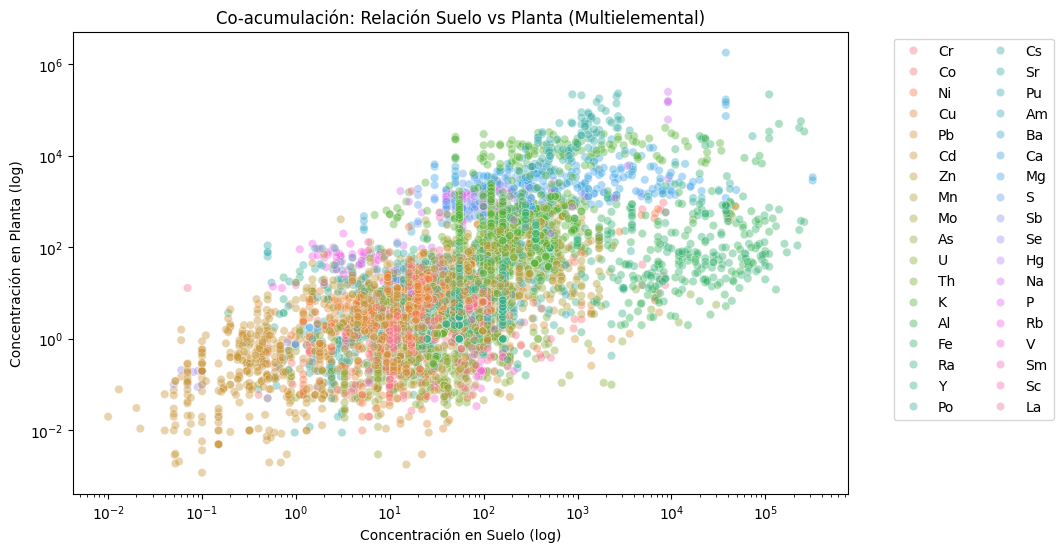

In [17]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 2. CREACIÓN DE VARIABLES NECESARIAS
df['CR_val'] = pd.to_numeric(df['CR'], errors='coerce')
df['C_plant_val'] = pd.to_numeric(df['C_plant'], errors='coerce')
df['C_soil_val'] = pd.to_numeric(df['C_soil'], errors='coerce')
df['pH_val'] = pd.to_numeric(df['pH'], errors='coerce')

# --- GRÁFICA 1: ¿Se absorben los radionúclidos y metales juntos? ---
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='C_soil_val', y='C_plant_val', hue='Element', alpha=0.4)
plt.xscale('log')
plt.yscale('log')
plt.title("Co-acumulación: Relación Suelo vs Planta (Multielemental)")
plt.xlabel("Concentración en Suelo (log)")
plt.ylabel("Concentración en Planta (log)")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', ncol=2) # Leyenda fuera para que no tape
plt.show()

Lo que observo de la gráfica es que existe una relación directamente proporcional. A mayor concentración del suelo, se tiene mayor concentración en la planta. Debido a la cantidad de observaciones y que no diferencio los metales y demas elementos en la siguiente grafica se agruparán los elementos  en grupos quimicos para entender en qué grupo de elementos existe mayor absorción.  

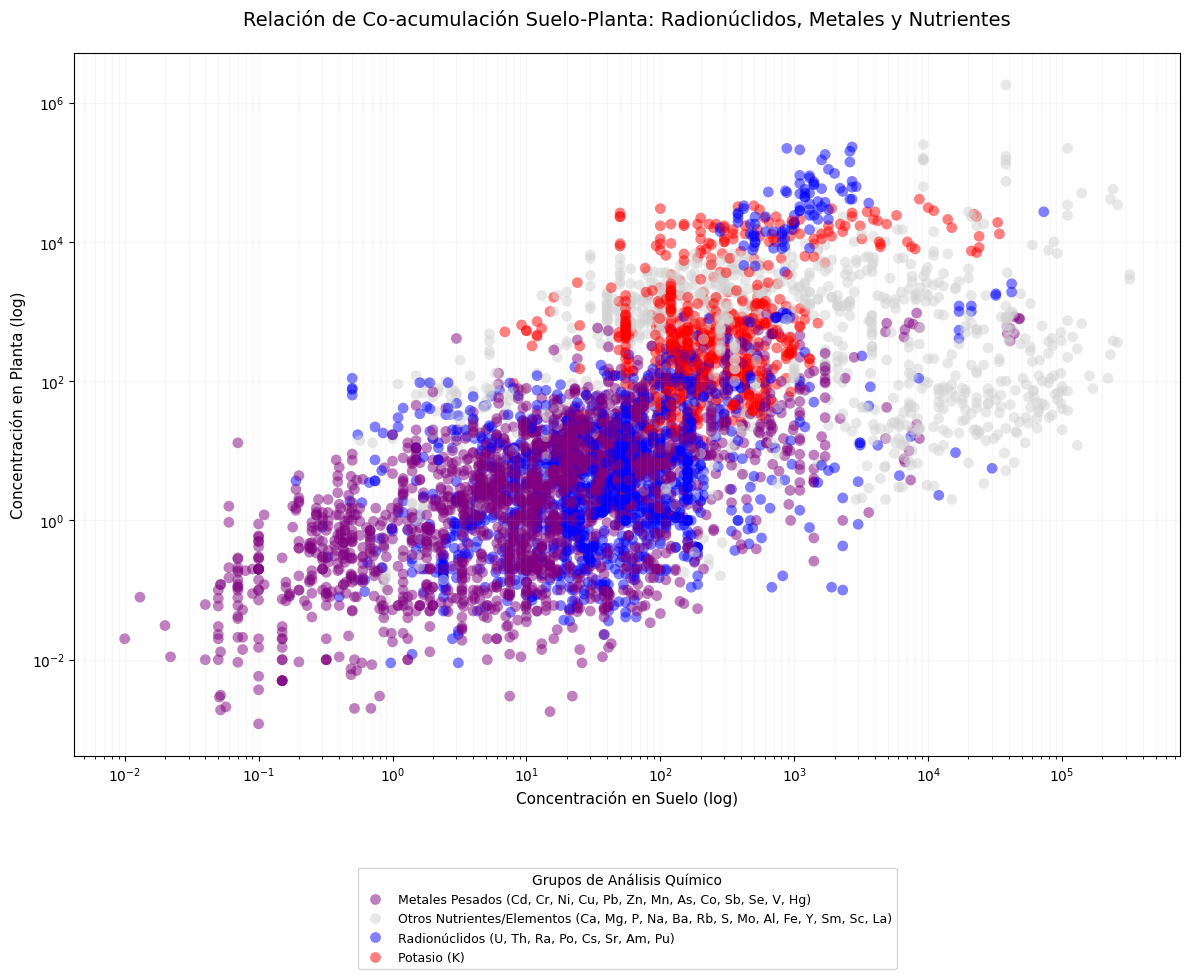

In [18]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Definir las listas completas según tu dataset de 36 elementos
rad_list = ['U', 'Th', 'Ra', 'Po', 'Cs', 'Sr', 'Am', 'Pu']
metales_list = ['Cd', 'Cr', 'Ni', 'Cu', 'Pb', 'Zn', 'Mn', 'As', 'Co', 'Sb', 'Se', 'V', 'Hg']
nutrientes_list = ['Ca', 'Mg', 'P', 'Na', 'Ba', 'Rb', 'S', 'Mo', 'Al', 'Fe', 'Y', 'Sm', 'Sc', 'La']

# 2. Función para crear etiquetas con el detalle químico
def etiquetas_finales(elemento):
    if elemento == 'K':
        return "Potasio (K)"
    elif elemento in rad_list:
        return f"Radionúclidos ({', '.join(rad_list)})"
    elif elemento in metales_list:
        return f"Metales Pesados ({', '.join(metales_list)})"
    elif elemento in nutrientes_list:
        return f"Otros Nutrientes/Elementos ({', '.join(nutrientes_list)})"
    else:
        return "Otros"

# 3. Aplicamos al dataframe
df['Grupo_Final'] = df['Element'].apply(etiquetas_finales)

# 4. Configuración de la Gráfica
plt.figure(figsize=(12, 10)) # Se aumenta la altura para dar espacio a la leyenda abajo

colores_tesis = {
    f"Radionúclidos ({', '.join(rad_list)})": 'blue',
    "Potasio (K)": 'red',
    f"Metales Pesados ({', '.join(metales_list)})": 'purple',
    f"Otros Nutrientes/Elementos ({', '.join(nutrientes_list)})": 'lightgrey'
}

sns.scatterplot(
    data=df,
    x='C_soil_val',
    y='C_plant_val',
    hue='Grupo_Final',
    palette=colores_tesis,
    alpha=0.5,
    s=60,
    edgecolor='none'
)

plt.xscale('log')
plt.yscale('log')

plt.title("Relación de Co-acumulación Suelo-Planta: Radionúclidos, Metales y Nutrientes", fontsize=14, pad=20)
plt.xlabel("Concentración en Suelo (log)", fontsize=11)
plt.ylabel("Concentración en Planta (log)", fontsize=11)

# 5. MOVER LEYENDA ABAJO
# 'bbox_to_anchor' ajusta la posición; 'loc' el punto de anclaje; 'ncol' divide en filas
plt.legend(
    title="Grupos de Análisis Químico",
    loc='upper center',
    bbox_to_anchor=(0.5, -0.15),
    ncol=1,
    fontsize=9,
    frameon=True
)

plt.grid(True, which="both", ls="-", alpha=0.1)
plt.tight_layout() # Ajusta automáticamente para que no se corte la leyenda
plt.show()

Esta gráfica clasifica los grupos en metales pesados, otros nutrientes, radionúclidos y el potasio, la cual me permite observar que la planta tiene caminos de absorción diferentes para cada uno de los elementos.

Para los metales pesados, se observa que están agrupados en la parte inferior izquierda. Aunque existan concentraciones altas de metales pesados, la planta no tiene hiperacumulación de estos, aunque observo un grupo pequeño en la parte superior que sí puede presentar este fenómeno.

Los radionúclidos (azul) muestran un patrón muy similar a la de los metales, lo que confirma que procesos de absorción en la planta pueden ocurrir simultáneamente entre estos grupos, debido a que sus concentraciones están en cantidades iguales y biodisponibles.

La distribución del potasio (rojo) muestra que su biodisponibilidad en el suelo es mayor y, al ser un nutriente esencial, la planta tiene buenos caminos de absorción.

Sobre los otros nutrientes (gris), estos se encuentran en la parte superior derecha, con mayores concentraciones en el suelo y en la planta, lo que indica una mayor absorción de estos elementos, ya que algunos, al ser nutrientes esenciales, mostrabdo procesos mas eficientes en cuanto a la absorción y acumulación.

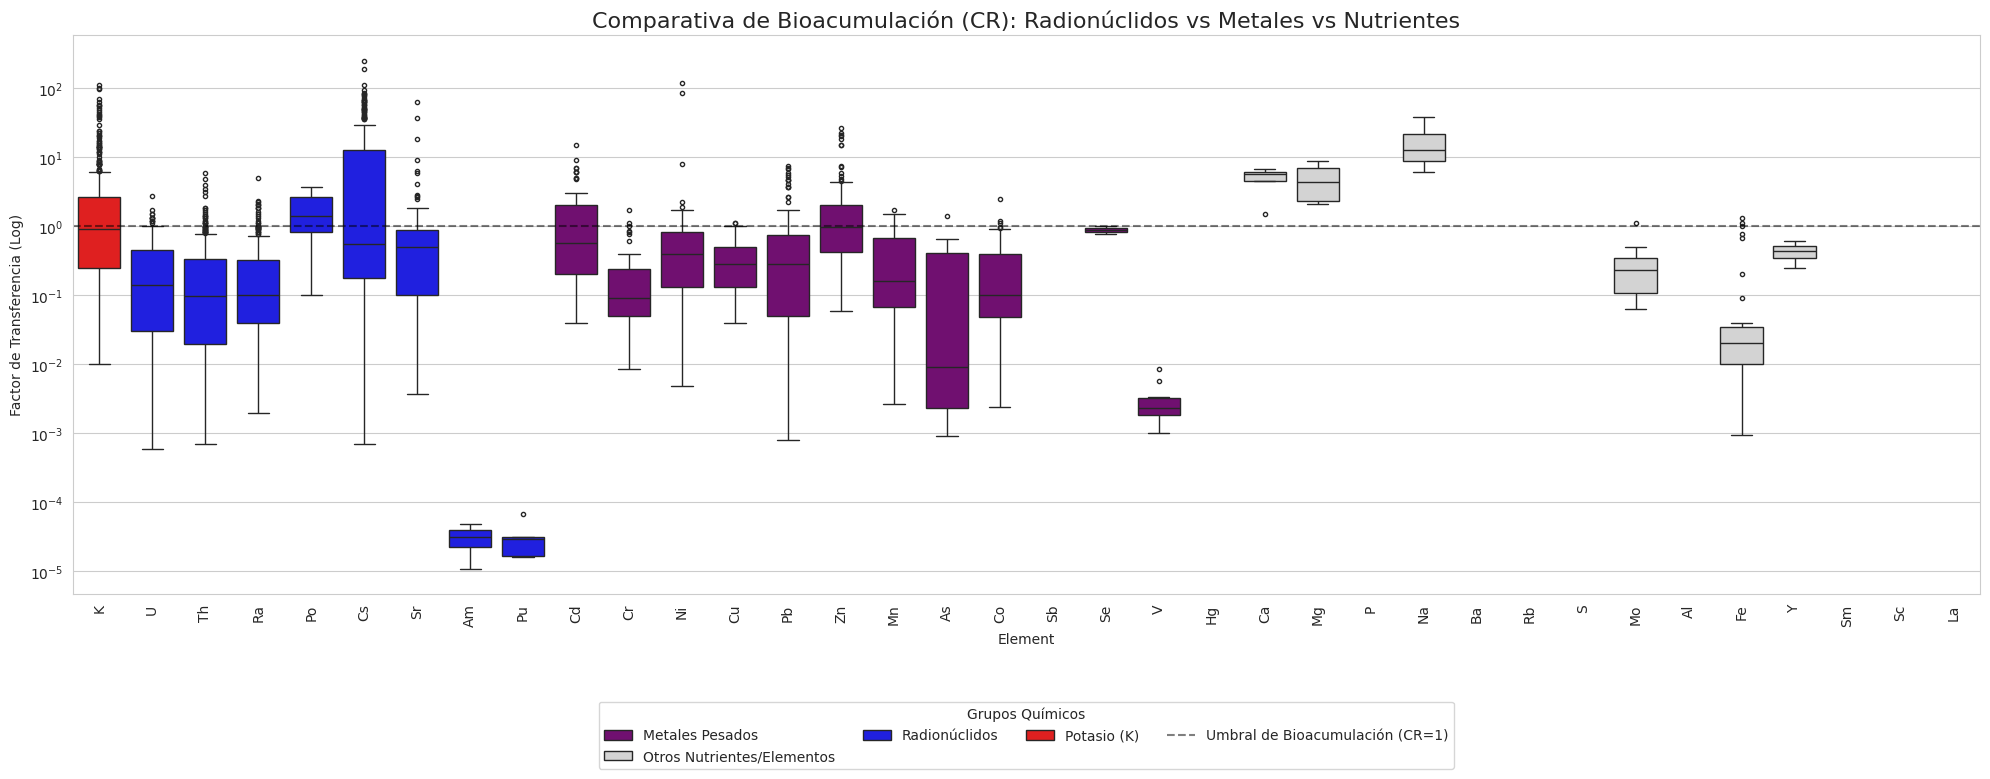

In [32]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Aseguramos columnas numéricas
df['CR_v'] = pd.to_numeric(df['CR'], errors='coerce')

# 2. Listas de control
rad_list = ['U', 'Th', 'Ra', 'Po', 'Cs', 'Sr', 'Am', 'Pu']
metales_list = ['Cd', 'Cr', 'Ni', 'Cu', 'Pb', 'Zn', 'Mn', 'As', 'Co', 'Sb', 'Se', 'V', 'Hg']
nutrientes_list = ['Ca', 'Mg', 'P', 'Na', 'Ba', 'Rb', 'S', 'Mo', 'Al', 'Fe', 'Y', 'Sm', 'Sc', 'La']

# 3. Función para asignar Grupo
def asignar_grupo(elemento):
    if elemento == 'K': return "Potasio (K)"
    if elemento in rad_list: return "Radionúclidos"
    if elemento in metales_list: return "Metales Pesados"
    if elemento in nutrientes_list: return "Otros Nutrientes/Elementos"
    return "Otros"

df['Grupo_Color'] = df['Element'].apply(asignar_grupo)

# 4. Paleta de colores EXACTA
paleta_tesis = {
    "Potasio (K)": 'red',
    "Radionúclidos": 'blue',
    "Metales Pesados": 'purple',
    "Otros Nutrientes/Elementos": 'lightgrey',
    "Otros": 'darkgrey'
}

# 5. GRÁFICA DE CAJAS (BOXPLOT) AMPLIADA
# Aumentamos el ancho (20) para que quepan los grises
plt.figure(figsize=(20, 8))
sns.set_style("whitegrid")

# Ordenamos para que se vean: Rojo -> Azul -> Morado -> Gris
orden_total = ['K'] + rad_list + metales_list + nutrientes_list
elementos_presentes = [e for e in orden_total if e in df['Element'].unique()]

ax = sns.boxplot(
    data=df,
    x='Element',
    y='CR_v',
    hue='Grupo_Color',
    palette=paleta_tesis,
    order=elementos_presentes,
    dodge=False,
    fliersize=3 # Tamaño de los puntos de valores extremos
)

# 6. Formato y Escala
plt.yscale('log')
plt.axhline(y=1, color='black', linestyle='--', alpha=0.5, label='Umbral de Bioacumulación (CR=1)')

plt.title("Comparativa de Bioacumulación (CR): Radionúclidos vs Metales vs Nutrientes", fontsize=16)
plt.xticks(rotation=90, fontsize=10) # Rotación a 90 grados para que no se traslapen los nombres
plt.ylabel("Factor de Transferencia (Log)")

# Leyenda abajo
plt.legend(title="Grupos Químicos", loc='upper center', bbox_to_anchor=(0.5, -0.18), ncol=4)

plt.tight_layout()
plt.show()

El Factor de Transferencia $CR$ muestra las diferencias entre los grupos, con la línea punteada $CR = 1$ que indica el umbral a partir del cual un elemento se considera bioacumulable (más concentración del elemento en la planta que en el suelo).

* Los radionúclidos (azules): el polonio (Po) y el cesio (Cs) son los más preocupantes. Sus cajas están posicionadas por encima del umbral de 1, lo que confirma que la planta los extrae activamente del suelo. En particular, el Cs muestra una dispersión alta lo que indica que, bajo ciertas condiciones tropicales, su acumulación puede ser extrema.
* El  Potasio (Rojo): La caja del Potasio (K) muesra una acumulacion, pero como ya se ha dicho antes que es un nutrinete esencial par la planta se justifica su acumulacion.
* Metales Pesados y Exclusión (Púrpura): A diferencia de los anteriores, la mayoría de los metales pesados como el Cromo (Cr), Plomo (Pb) o Arsénico (As) tienen sus cajas por debajo del umbral de 1. Esto demuestra que la planta es mucho más eficiente filtrando metales pesados que radionúclidos. El Zinc (Zn) y el Cadmio (Cd) son las excepciones, mostrando una mayor movilidad biológica.    
* Elementos Inertes: Radionúclidos como el americio (Am) y el plutonio (Pu) aparecen en la base total del gráfico ($10^{-5}$), indicando que su transferencia a la planta en estas condiciones es prácticamente nula.

* Elementos clave: magnesio (Mg), calcio (Ca) y sodio (Na) se sitúan por encima del umbral de CR = 1, debido a su papel esencial en el funcionamiento de la planta.

El magnesio (Mg) es el elemento principal de la molécula de clorofila. La planta lo absorbe en grandes cantidades y con prioridad, ya que sin él no sería capaz de llevar a cabo la fotosíntesis ni convertir la energía solar en energía química biomasa.

El calcio (Ca): la planta lo absorbe del suelo para proporcionar soporte físico a cada nuevo compartimento (hojas, tallos, frutos).

El sodio (Na) muestra uno de los niveles de CR más altos en el gráfico, lo cual es notable. Esto se debe a que las plantas tropicales lo emplean para equilibrar el agua (turgencia) en las células y regular la apertura de los estomas, en particular en situaciones de alta transpiración.

**¿En qué compartimento hay mayor acumulación?**

Para analizar en qué compartimento hay una mayor acumulación, se utilizara la variable factor de transferencia CR en lugar de las concetraciones absolutas de la planta ($C_{plant}$).
Esta decision se fundamenta en:
 * El CR me ayuda a comparar la eficiencia de absorción entre elementos con órdenes de magnitud muy diferentes. Mientras que nutrientes como el Potasio están en concentraciones de partes por mil, los radionúclidos generalmente están en trazas (partes por billón).
 * Dado que la concentración en la planta depende directamente de la cantidad en el suelo ($C_{soil}$), el CR funciona como un indicador de la capacidad biológica de la planta para transportar ese elemento a la raíz, el tallo o las hojas, sin importar si el suelo está muy contaminado o poco.
 * El uso de CR ayuda a identificar compartimentos bioacumuladores (cuando $CR > 1$), lo cual es crucial para abordar la pregunta sobre el riesgo de contaminantes en la cadena alimentaria.

/tmp/ipython-input-398/1473684916.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='Compartment', y='CR_val', estimator='mean', errorbar=None, palette='magma')


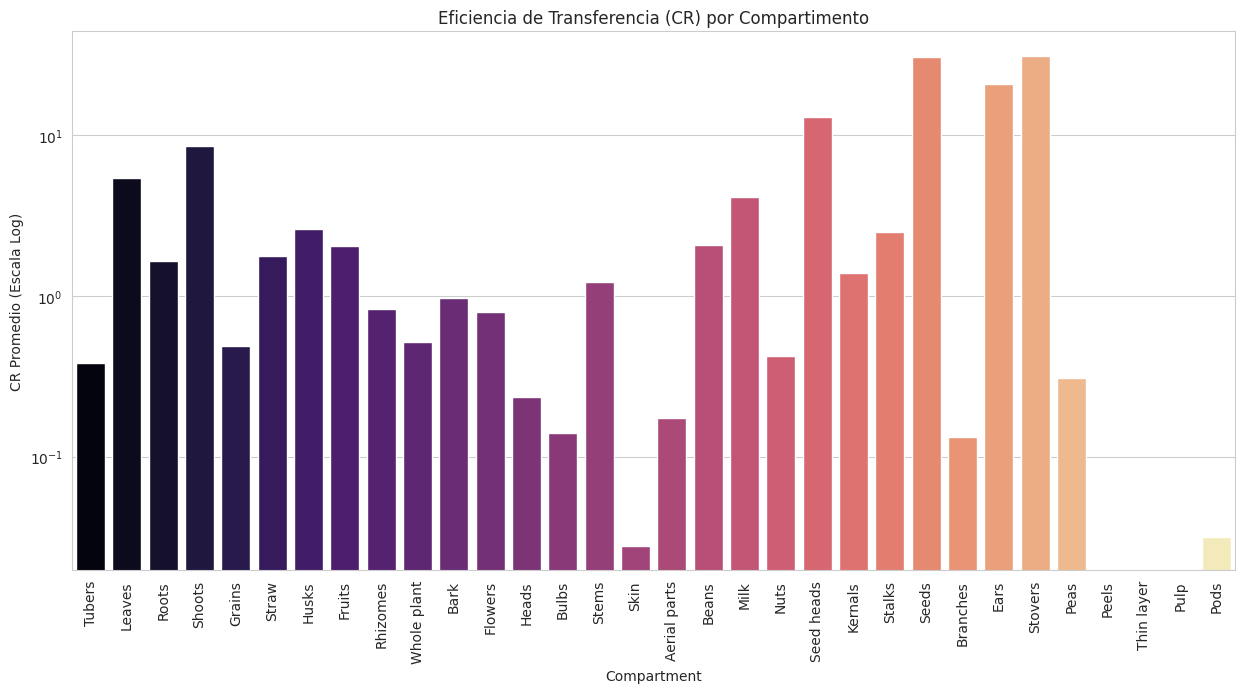

In [39]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 2. CREACIÓN DE VARIABLES NECESARIAS
df['CR_val'] = pd.to_numeric(df['CR'], errors='coerce')
df['C_plant_val'] = pd.to_numeric(df['C_plant'], errors='coerce')
df['C_soil_val'] = pd.to_numeric(df['C_soil'], errors='coerce')
df['pH_val'] = pd.to_numeric(df['pH'], errors='coerce')


# --- GRÁFICA 2: ¿En qué compartimento hay mayor acumulación? ---
plt.figure(figsize=(15, 7))
# Usamos el promedio (mean) del factor de transferencia (CR)
sns.barplot(data=df, x='Compartment', y='CR_val', estimator='mean', errorbar=None, palette='magma')
plt.yscale('log')
plt.xticks(rotation=90)
plt.title("Eficiencia de Transferencia (CR) por Compartimento")
plt.ylabel("CR Promedio (Escala Log)")
plt.show()

La gráfica indica que muchos compartimentos vegetales funcionan como acumuladores activos, porque su promedio de CR supera 1. Esto confirma que la planta posee una alta capacidad para transferir radionúclidos y metales desde el suelo hacia diferentes órganos.

 **Los "Súper-Acumuladores" (CR más alto):** Los compartimentos con mayor eficiencia de transferencia son Seeds (Semillas), Stovers (Rastrojo/Follaje seco) y Ears (Mazorcas/Espigas). Estas muestran las barras más altas en la gráfica, señalando que son los principales puntos de acumulación final.

**Compartimentos con Alta Acumulación**:Otros órganos con un CR mucho mayor a 1 incluyen
- Shoots (Brotes) y Leaves (Hojas). Esto indica una alta transferencia hacia las partes verdes de la planta.

- Semillas, leche (etapa lechosa del grano) y frijoles: fortalecen la tendencia de acumulación en las partes reproductivas y de almacenamiento.

- Roots (Raíces): Confirman que la raíz es la primera barrera de entrada con un CR > 1, pero es superada por los órganos aéreos mencionados arriba.

- Straw, Husks, Fruits y Stalks: También superan el umbral, mostrando una distribución generalizada en toda la estructura vegetal.


Por el contrario, áreas como la piel, los bulbos y las partes aéreas muestran los valores de CR más bajos (CR < 1). Esto indica que la planta utiliza mecanismos de exclusión selectiva, limitando la entrada de metales y radionúclidos a ciertos tejidos y protegiendo órganos vitales o de reserva, como los tubérculos y la pulpa, incluso cuando estos elementos son abundantes en el suelo.

¿Variables como el pH y la materia orgánica pueden ayudar a la fijación de metales y radionúclidos en las plantas?

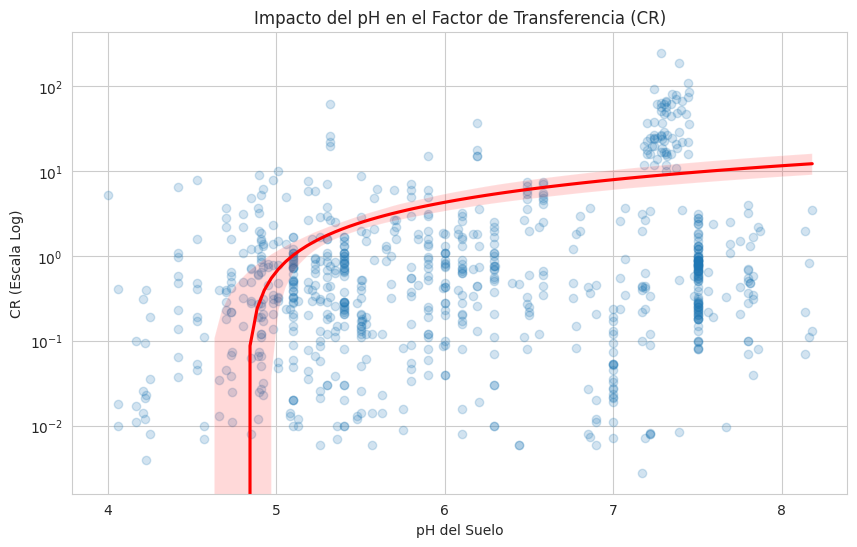

In [38]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 2. CREACIÓN DE VARIABLES NECESARIAS
df['CR_val'] = pd.to_numeric(df['CR'], errors='coerce')
df['C_plant_val'] = pd.to_numeric(df['C_plant'], errors='coerce')
df['C_soil_val'] = pd.to_numeric(df['C_soil'], errors='coerce')
df['pH_val'] = pd.to_numeric(df['pH'], errors='coerce')

# --- GRÁFICA 3: ¿El pH facilita la absorción? ---
plt.figure(figsize=(10, 6))
sns.regplot(data=df, x='pH_val', y='CR_val', scatter_kws={'alpha':0.2}, line_kws={'color':'red'})
plt.yscale('log')
plt.title("Impacto del pH en el Factor de Transferencia (CR)")
plt.xlabel("pH del Suelo")
plt.ylabel("CR (Escala Log)")
plt.show()

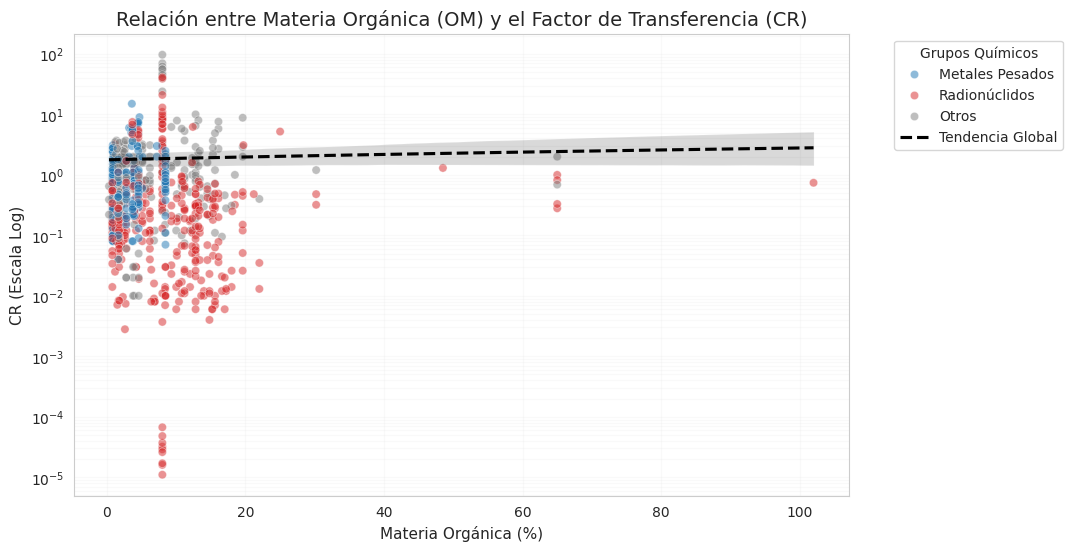

In [45]:
# Aseguramos que la variable OM sea numérica
df['OM_val'] = pd.to_numeric(df['OM'], errors='coerce')

# --- GRÁFICA 4: ¿La Materia Orgánica (OM) frena la absorción? ---
plt.figure(figsize=(10, 6))

# Usamos lmplot para poder separar por los grupos que ya definimos
# Esto te permitirá ver si la materia orgánica afecta igual al Potasio que a los Radionúclidos
sns.scatterplot(data=df, x='OM_val', y='CR_val', hue='Grupo_Final',
                palette=colores_tesis, alpha=0.5)

# Añadimos una línea de tendencia general para ver el comportamiento global
sns.regplot(data=df, x='OM_val', y='CR_val', scatter=False, color='black',
            label='Tendencia Global', line_kws={'linestyle':'--'})

plt.yscale('log')
plt.title("Relación entre Materia Orgánica (OM) y el Factor de Transferencia (CR)", fontsize=14)
plt.xlabel("Materia Orgánica (%)", fontsize=11)
plt.ylabel("CR (Escala Log)", fontsize=11)
plt.legend(title="Grupos Químicos", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, which="both", ls="-", alpha=0.1)
plt.show()

El pH del suelo puede ser un  factor que regula la movilidad de los contaminantes, ya que determina qué fracción de los elementos en el suelo está realmente disponible para las plantas.
La gráfica muestra que en condiciones de acidez muy alta $(pH < 4.8)$, la transferencia es muy baja, probablemente porque el metal está en formas químicas no absorbibles o por la interferencia de iones como el aluminio. Sin embargo, entre un pH de 4.8 y 5.5, se observa un aumento en el factor de transferencia, lo que sugiere que pequeños incrementos en el pH movilizan los radionúclidos y metales presentes en el suelo, facilitando su entrada a la raíz.
Por otro lado, la materia orgánica ($OM$) presenta un comportamiento de independencia frente al factor de transferencia (CR), evidenciado por una línea de tendencia casi plana.
En resumen, la disponibilidad es más influenciada por las variaciones de pH que por la capacidad de retener materia orgánica, lo que justifica que la acidez sea el factor más importante para determinar el riesgo de transferencia en estos ecosistemas tropicales.

# 5. Interpretaciones Iniciales
**¿Qué tendencias o patrones básicos se observan?**

* La mayoría de las observaciones corresponden a radionúclidos naturales (como U, Th, Ra, Po) y metales pesados tóxicos. Las concentraciones más altas se encuentran en elementos como K (potasio) y Cs (cesio), que presentan niveles elevados en las plantas (media de C_plant ~2568 mg/kg o Bq/kg para radionúclidos, en comparación con aproximadamente 22 mg/kg para los metales).
* El Factor de Transferencia (CR) muestra comportamientos muy distintos dependiendo del contaminante. En radionúclidos naturales como U, Th, Ra y Po, el CR es bajo (promedio 0.33, mediana 0.11), reflejando una exclusión parcial por las raíces y una transferencia limitada a la planta. Sin embargo, en radionúclidos de origen antropogénico, como el cesio (CR promedio 11.57), y en metales pesados como níquel (CR 6.22) y cadmio (CR 1.76), el CR es alto, lo que indica una fuerte absorción y acumulación en los tejidos vegetales, especialmente en ecosistemas tropicales con suelos ácidos.

* Los compartimentos vegetales muestran un sesgo hacia 'Fruits' (frutos) y 'Leaves' (hojas), que son las partes comestibles más relevantes en dietas tropicales (por ejemplo, banano, mango, papaya, verduras de hoja). Este predominio no es casual: el programa MODARIA II de la IAEA priorizó muestreos en compartimentos comestibles para evaluar mejor el riesgo de exposición humana a través de alimentos contaminados. Como resultado, se reportan más registros y CR más altos en hojas y frutos para elementos móviles como Cs y metales pesados (que se translocan fácilmente desde raíces a partes aéreas), mientras que las raíces acumulan más NORM pesados (U, Th, Ra) con CR bajos, aunque con menos datos disponibles sobre raíces y tallos. Este sesgo refleja un enfoque práctico en la protección radiológica (dosis por consumo), pero limita las comparaciones equilibradas de acumulación en todos los compartimentos planta.

**¿Qué limitaciones tiene la base de datos?**

* Esta base de datos presenta un porcentaje elevado de valores faltantes en variables edáficas importantes como pH $(~77-78%)$, materia orgánica $(OM, ~84%)$, textura $(~79%)$ y capacidad de intercambio catiónico $(CEC, ~82%)$, lo cual restringe la realización de análisis precisos sobre la influencia de las propiedades del suelo en la absorción.

* Hay unidades mixtas en las concetraciones de los elementos (Bq/kg para radionúclidos vs. mg/kg para metales pesados), lo que hace dificil hacer comparaciones, se necesita la normalizaciond de los datos.
* Se tiene un sesgo en compartimentos (dominados por "Fruits" y "Leaves", ~40% de registros), posiblemente por el objetivo del propio estudio establecido en MODARIA II que es el enfoque en partes comestibles, lo que subestima acumulación en raíces o tallos y no refleja distribución uniforme en plantas.


**¿Qué hipótesis iniciales podrían plantearse para análisis posteriores?**

* La presencia de metales pesados tóxicos, como Ni y Cd, favorece la absorción de radionúclidos antropogénicos, como Cs, por competencia catiónica en las raíces, lo que incrementa el CR en los compartimentos aéreos.
* La acumulación de radionúclidos es mayor en hojas y frutos que en raíces o tallos, especialmente en suelos ácidos $(pH < 6)$.
* Las diferencias en el Factor de Transferencia (CR) entre contaminantes de origen natural y de origen humano (antropogénicos) dependen del compartimento de la planta donde se miden, y en general los contaminantes antropogénicos se mueven (translocan) más fácilmente hacia las partes superiores de la planta (hojas, tallos, frutos).
* Las escpecies con $CR > K$ (4.05) para Cs o Ni podrían actuar como hiperacumuladoras, pero tambien como vestores de riesgo radiologico.


* Especies cosmopolitas ampliamente cultivadas en regiones tropicales, como banano (Musa spp.), papaya (Carica papaya), arroz (Oryza sativa) y yuca (Manihot esculenta), que predominan en los registros de partes comestibles en el dataset MODARIA II, muestran una mayor translocación y acumulación de radionúclidos antropogénicos (principalmente Cs-137) y metales pesados tóxicos (Ni, Cd, Zn) en frutos, granos y tubérculos. Esto aumenta el riesgo de entrada en la cadena alimentaria humana, pero también las convierte en potenciales bioindicadoras o candidatas para estrategias de fitorremediación asistida con hongos micorrícicos o saprófitos, capaces de reducir la biodisponibilidad de estos contaminantes en suelos ácidos tropicales.

# 6.  Conclusiones


* El análisis exploratorio revela una transferencia de elementos en plantas tropicales: los NORM pesados (U, Th, Ra) se retienen en suelo con CR bajo (~0.33), mientras que los elementos antropogénicos (Cs ~11.57) y metales pesados (Ni ~6.22, Cd ~1.76) muestran una bioconcentración elevada, con patrones de coacumulación sugeridos por correlaciones positivas entre C_soil y C_planta. La acumulación es mayor en frutos y hojas (sesgo en los datos), y propiedades edáficas como un pH ácido facilitan la biodisponibilidad.

* Se determinó que la absorción de radionúclidos en el trópico no ocurre de manera aleatoria, sino que está influenciada por la analogía nutricional. Elementos como Mg, Ca y Na, que muestran $CR > 1$ por su relevancia biológica en procesos como la fotosíntesis, la estructura celular y la regulación osmótica, pueden facilitar la entrada de contaminantes radiactivos. Además, se verificó que el pH puede controlar su movilidad, ya que cambios hacia la neutralidad aumentan la penetración de estos en el suelo.

* Este análisis exploratorio busca identificar los principales factores que influyen en la transferencia suelo-planta. Se concluye que el pH del suelo es un factor externo que promueve la movilización de contaminantes, superando el efecto de la materia orgánica. En conjunto, estos resultados brindan una respuesta clara a las preguntas de investigación, fundamentada en datos cuantitativos de la base MODARIA II.



# 7. Aporte de este análisis a mi propuesta de investigacion doctoral.  
Este análisis preliminar del conjunto de datos MODARIA II acerca de NORM en ambientes tropicales apoya de manera importante mi propuesta de investigación doctoral, al ofrecer una base empírica para entender cómo se comportan los radionúclidos en los sistemas  de absorcion planta-suelo.
Me ayuda a identificar factores importantes como un pH ácido promedio de 5,82 y una materia orgánica moderada-baja, con un promedio del 8,73%, que favorecen la biodisponibilidad y absorción de radionúclidos (por ejemplo, Cs-137, Sr-90, Ra-226, U-238) por las plantas, además de su coacumulación con metales pesados (por ejemplo, Cd, Zn, Pb, Ni).
Este análisis ofrece ideas prácticas para experimentos de bioremediación. Por ejemplo, elementos como Cs, que presentan CR altos en valores atípicos (hasta 250), actúan como hiperacumuladores en algunas especies vegetales tropicales, permitiéndome diseñar ensayos de fitoremediación para evaluar su capacidad de extraer contaminantes de suelos con NORM.
Finalmente, los datos plantean hipótesis intrigantes sobre el rol de hongos micorrízicos en raíces de plantas hiperacumuladoras. Dado que la acumulación es mayor en raíces para elementos inmóviles, se podría explorar si especies como Oryza sativa (arroz) o Musa spp. (banano) —comunes en el dataset— asocian hongos específicos (e.g., géneros Glomus o Rhizophagus) que potencian la absorción selectiva de radionúclidos y metales pesados. Esto abre vías para investigaciones sobre simbiosis micorrízica, analizando si estos hongos modulan la coacumulación (e.g., Cs con Zn), y podría llevar a ensayos en invernadero para identificar asociaciones que optimicen la bioremediación o reduzcan riesgos en la cadena alimentaria. En conjunto, este análisis fortalece mi propuesta al conectar datos empíricos con hipótesis aplicables, promoviendo un enfoque interdisciplinario entre radioecología, edafología y microbiología.

Finalmente, este analisis inicial me lleva a plantear hipótesis sobre el papel de los hongos micorrízicos en las raíces de plantas hiperacumuladoras. Como la acumulación es mayor en raíces para elementos inmóviles, puede ser útil investigar si especies como Oryza sativa (arroz) o Musa spp. (banano), presentes en el dataset, asocian hongos específicos (como los géneros Glomus o Rhizophagus) que puedan mejorar la absorción selectiva de radionúclidos y metales pesados.
Esto abre nuevas posibilidades para investigaciones sobre la simbiosis micorrízica, evaluando si estos hongos influyen en la coacumulación de elementos radiactivos y metales.

# Referencias
Las referencias técnicas se encuentran con hipervínculos dentro del desarrollo de la actividad.

**Fuente de los datos **
Conjunto de datos tropicales MODARIA II del OIEA.csv Datos no válidos
URL: https://data.iaea.org/dataset/62358dd9-48b0-4149-a10e-1caa675ddd04/resource/42c148b5-f43d-4b6f-b521-e4197fc23823/download/iaea-modaria-ii-tropical-dataset.csv

Esta compilación internacional de valores de la relación de concentración de radionucleidos e isótopos estables suelo-planta para entornos tropicales es un resultado del programa de Modelado y Datos para Evaluaciones de Impacto Radiológico II (MODARIA II) del OIEA (2016-2019) y se basa en la clasificación climática de Köppen-Geiger ( BECK et al., 2018 ). El conjunto de datos tropicales MODARIA II del OIEA está asociado con el TECDOC-1979 del OIEA: Transferencia de Radionucleidos Suelo-Planta en Entornos No Templados (2021) .